In [21]:
# Load the SavedModel
import tensorflow as tf
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import cv2
import pandas as pd
import os
from obspy import read, Trace
import numpy as np
from random import randrange
import matplotlib.pyplot as plt


In [22]:
model = tf.keras.models.load_model('./model8k_v4_org_sabah')

In [23]:
""""
model = models.Sequential(
    [
        layers.Conv1D(512, 3, activation="relu", input_shape=(X_train.shape[1], X_train.shape[2])),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Conv1D(32, 3, activation="relu"),
        layers.Dropout(0.2),
        layers.MaxPooling1D(2),
        layers.Conv1D(8, 3, activation="relu"),
        layers.MaxPooling1D(2),
        layers.Flatten(),
        # model.add(LSTM(64)),
        layers.Dense(8, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
"""

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 7998, 512)         2048      
                                                                 
 max_pooling1d (MaxPooling1D  (None, 3999, 512)        0         
 )                                                               
                                                                 
 conv1d_1 (Conv1D)           (None, 3997, 64)          98368     
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 1998, 64)         0         
 1D)                                                             
                                                                 
 conv1d_2 (Conv1D)           (None, 1996, 32)          6176      
                                                                 
 dropout (Dropout)           (None, 1996, 32)          0

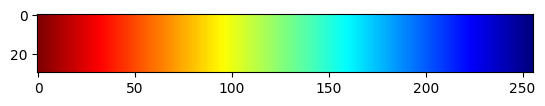

In [24]:


color_img = cv2.imread('colorscale_jet.jpg')
colors = []
for i in range(0,len(color_img[15]), 5):
  colors.append(color_img[15][i])

plt.imshow(color_img)

In [25]:

def overlay_image(pred, pred_list, divide_number = 40):

    image = cv2.imread('trace_image.png')
    overlay = image.copy()

    # image sizes
    # print(overlay.shape)

    # Rectangle parameters
    x, y, w, h = 80, 60, 680, 150

    rect_with_offset = w // divide_number

    for i in range(divide_number):
        color_index = (100 - int(pred_list[i] * 100))
        # color_index = color_index
        if pred < 0.49:
            color_index = 50 - color_index

        # print(color_index)
        b, g, r = colors[color_index // 2]
        overlay = cv2.rectangle(overlay, (x + i * rect_with_offset, y), (x + (i + 1) * rect_with_offset, y + h), (int(b), int(g), int(r)), -1)

    # A filled rectangle
    # cv2.rectangle(overlay, (x, y), (x+w, y+h), (0, 200, 0), -1)

    alpha = 0.5  # Transparency factor.
    # Following line overlays transparent rectangle
    # over the image
    image_new = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0)

    cv2.imwrite("attention_signal.jpg", image_new)


    # concatenate both images
    image_new = cv2.vconcat([image, image_new])

    # cv2.imshow('Image', image_new)
    # cv2.waitKey(0)

    import matplotlib.pyplot as plt
    size = (10, 10)
    fig, ax = plt.subplots(figsize=size, )
    ax.imshow(image_new)
    plt.show()

    # cv2.destroyAllWindows()


In [26]:

def colorize(path, divide_number = 40, size_of_length_signal = 8000):

    trace = read(path)[0]
    # print(f" 1 {trace.data.shape}")
    # trace.plot()

    avg_num = np.average(trace.data)
    avg = np.zeros(size_of_length_signal // divide_number) + avg_num

    tmp = Trace(data = avg)
    # tmp.plot()

    predict_data = trace.data.reshape((1, len(trace.data), 1))

    t_pred = model.predict(predict_data)
    # for y_val in t_pred:
    #   print( "%.5f" % float(y_val), end = ", ")

    pred_list = []

    for i in range(divide_number):
        start_index = i * (len(predict_data[0]) // divide_number)

        # Protect the original data by making a copy
        original_data = predict_data.copy()

        # Replace the section of predict_data with yummydata
        for index in range(len(avg)):
            predict_data[0][index + start_index] = avg[index]
            # predict_data[0][start_index:end_index] = yummydata[:]

        d = np.array([])
        for index in range(len(trace.data)):
            # d.insert(predict_data[0][index][0])
            d = np.append(d, predict_data[0][index][0])

        d.reshape((1, size_of_length_signal))
        pl = Trace(data = d)
        # pl.plot()

        # # Perform the prediction on the modified predict_data
        y_pred = model.predict(predict_data)
        for y_val in y_pred[0]:
            # print("%.5f" % float(y_val), end=", ")
            pred_list.append(float(y_val))

        # # Restore the original data
        predict_data = original_data.copy()


    trace = Trace(data = predict_data[0].flatten())
    # trace.plot()
    trace.plot(outfile='trace_image.png')

    overlay_image(t_pred, pred_list, divide_number)
    
    return trace, t_pred, pred_list




In [27]:
import os

dataset = 'dataset8k_v4'

original_class_folder = "class2/original/"
original_trace_file_list = []

for trace_file in os.listdir(os.path.join(dataset, original_class_folder)):
    original_trace_file_list.append(trace_file)

original_trace_file_list.sort()

# for trace_file in original_trace_file_list:
#     print(f"original {trace_file}")

cs = 0 
index = 0

0 : dataset8k_v4/class2/original/201901_10_11__CIFT.BHZ.KO_original.sac
1/1 [==============================] - 0s 21ms/step


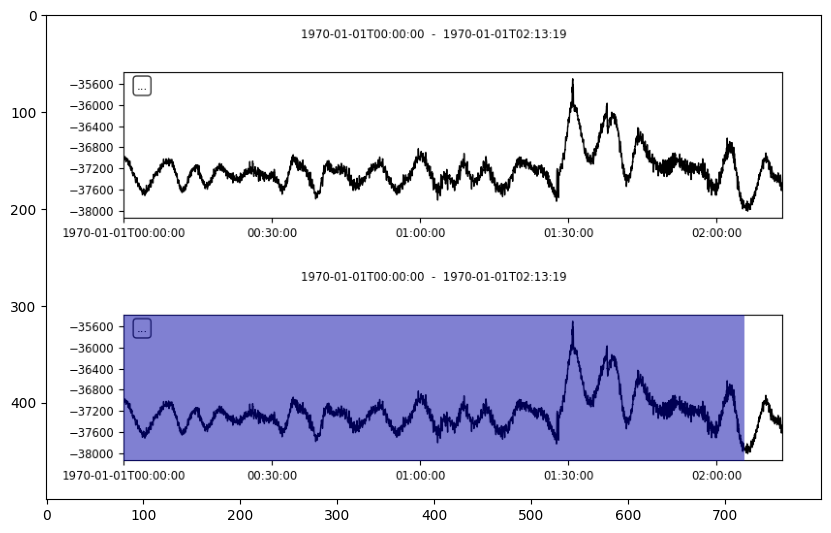

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

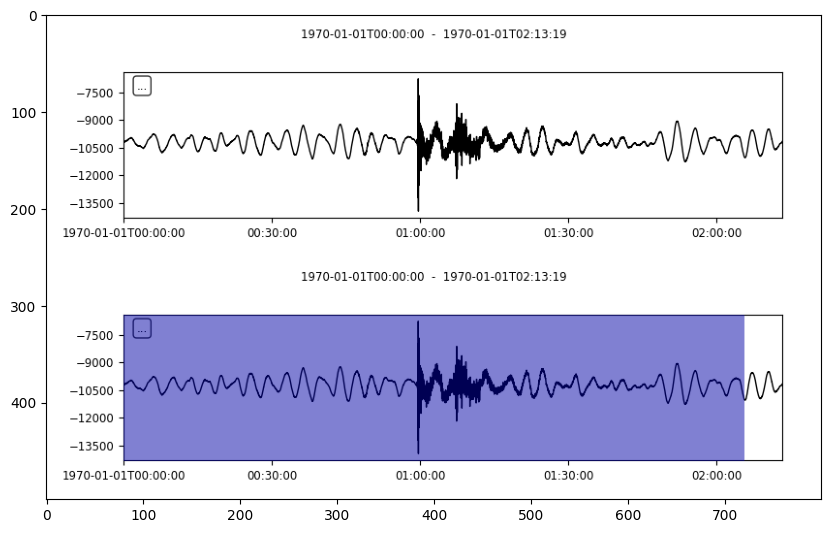

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

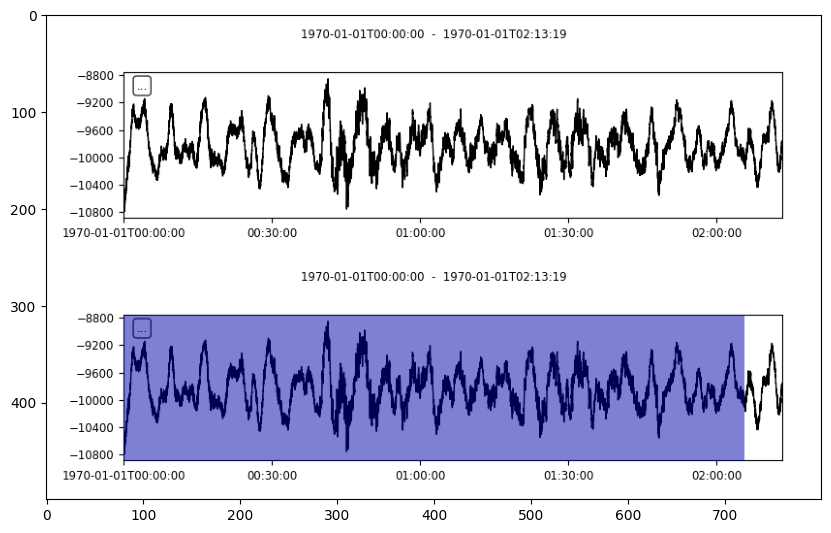

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

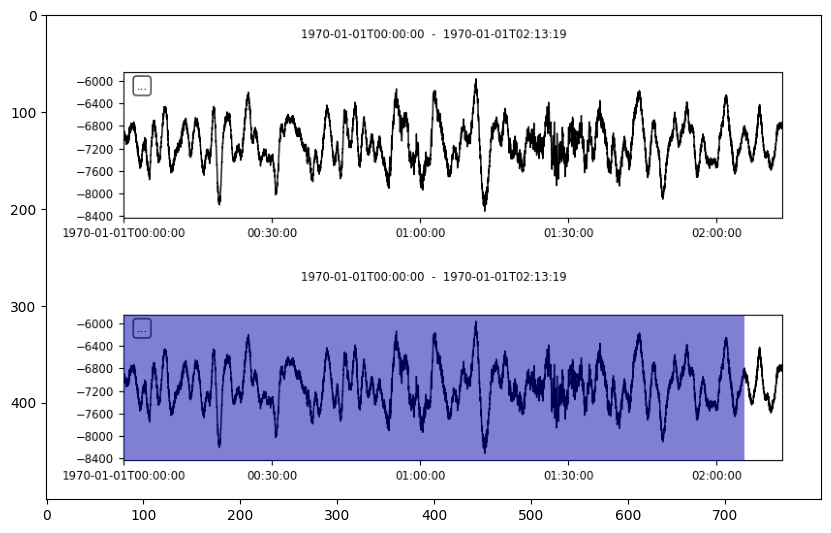

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

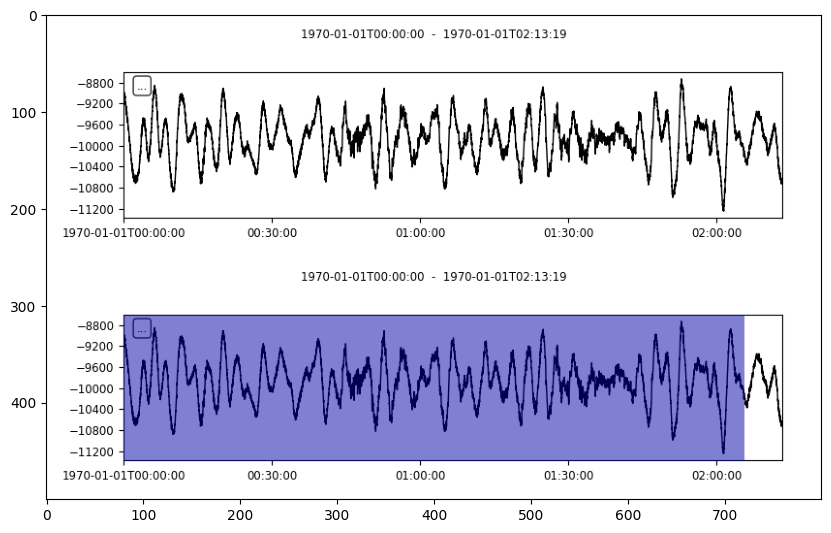

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

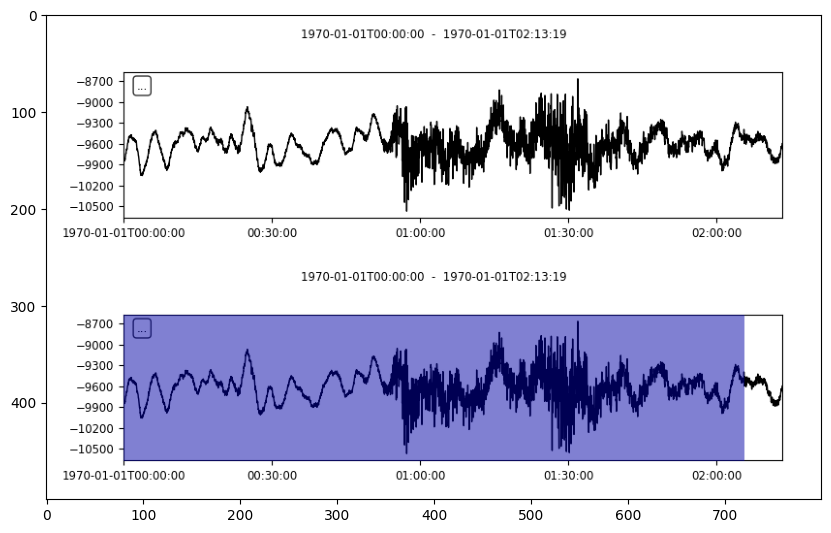

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

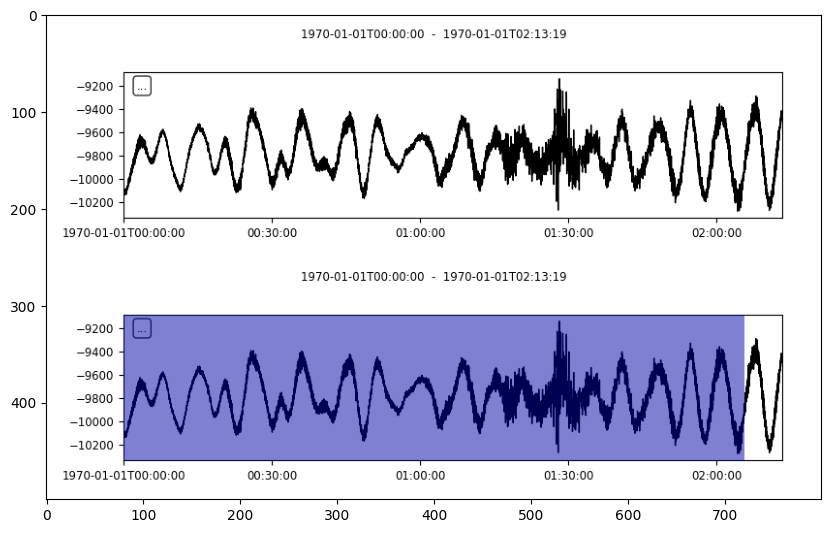

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

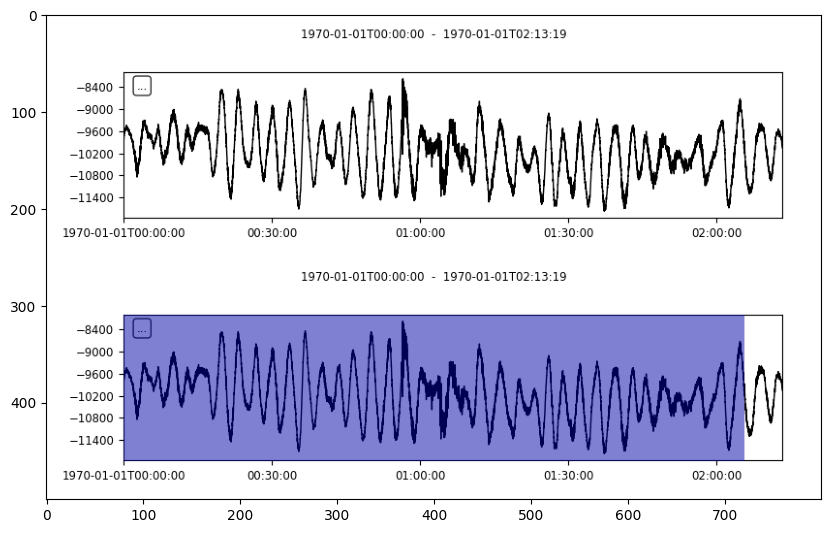

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

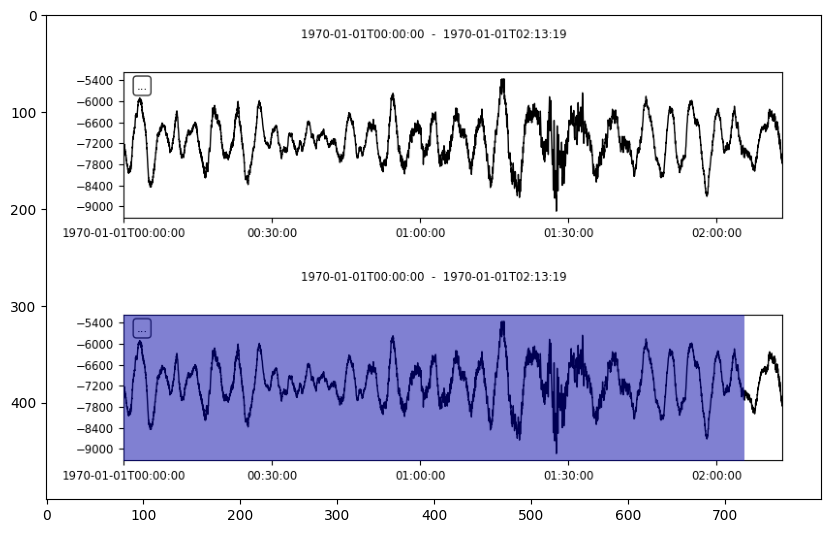

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

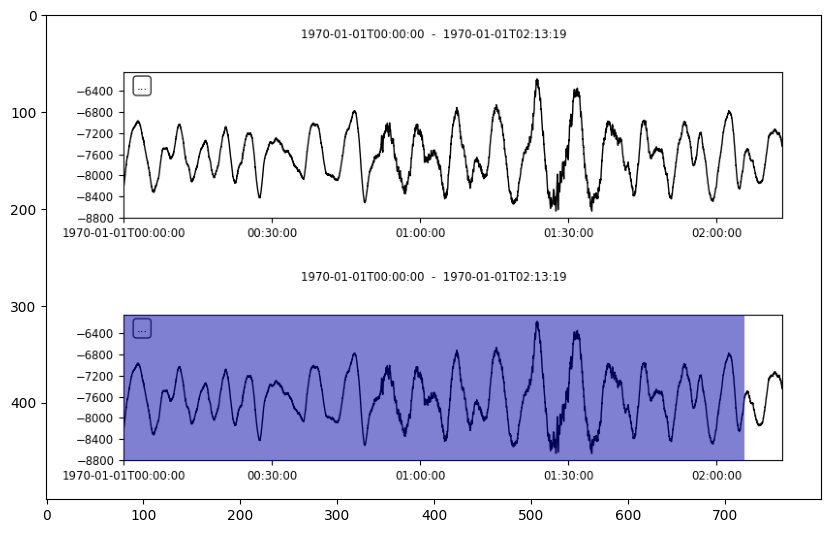

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

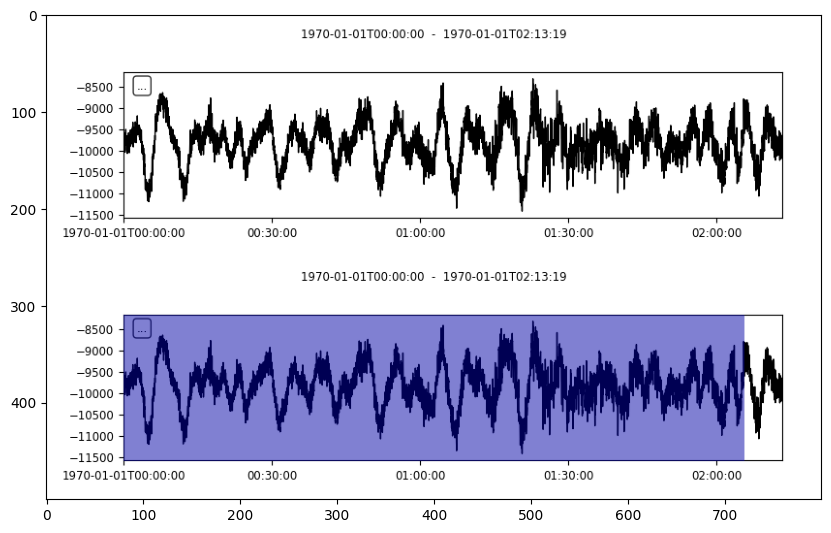

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

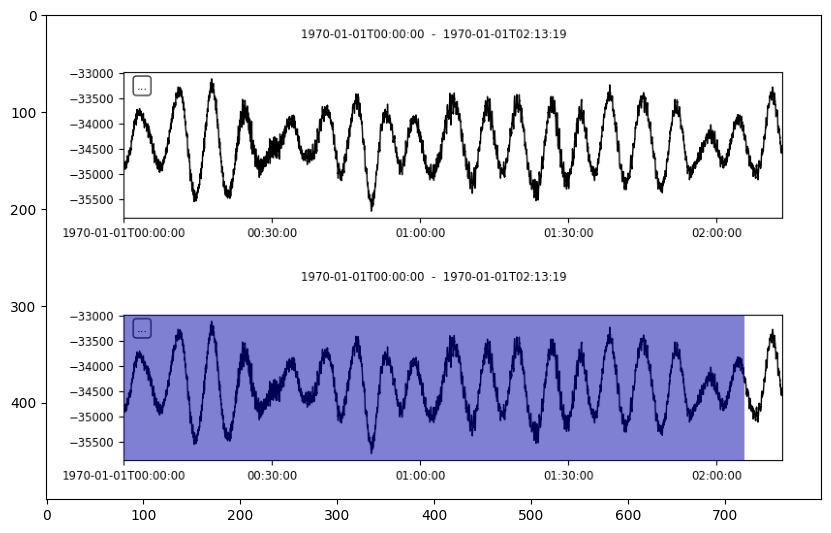

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

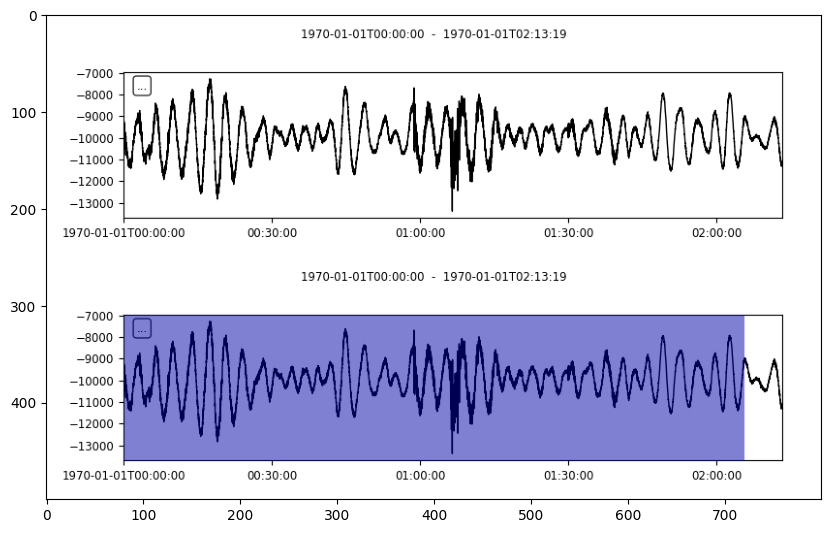

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

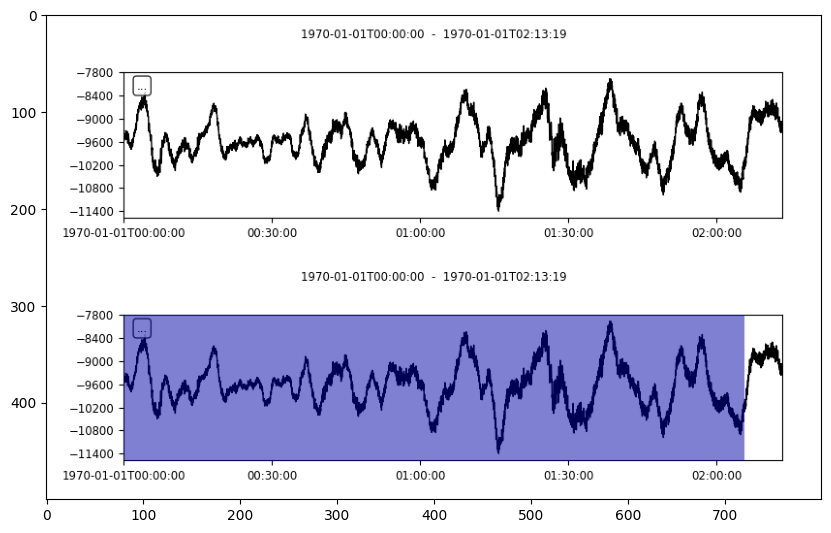

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

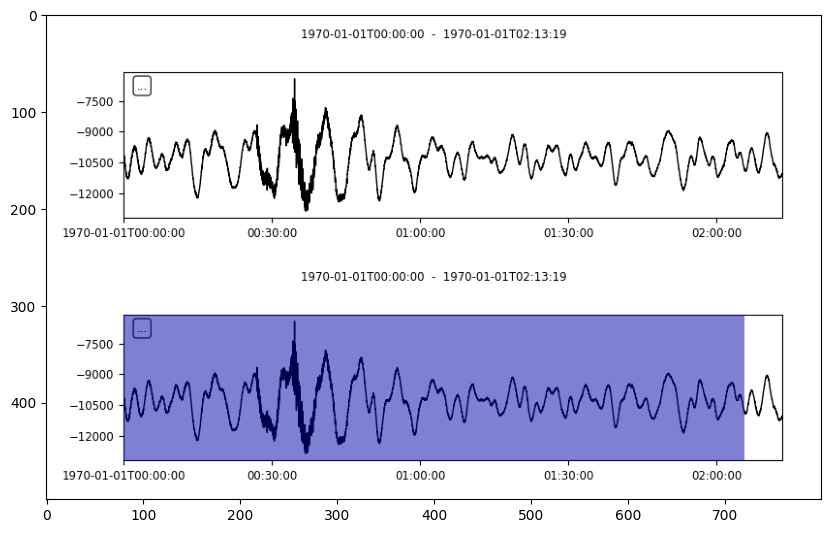

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

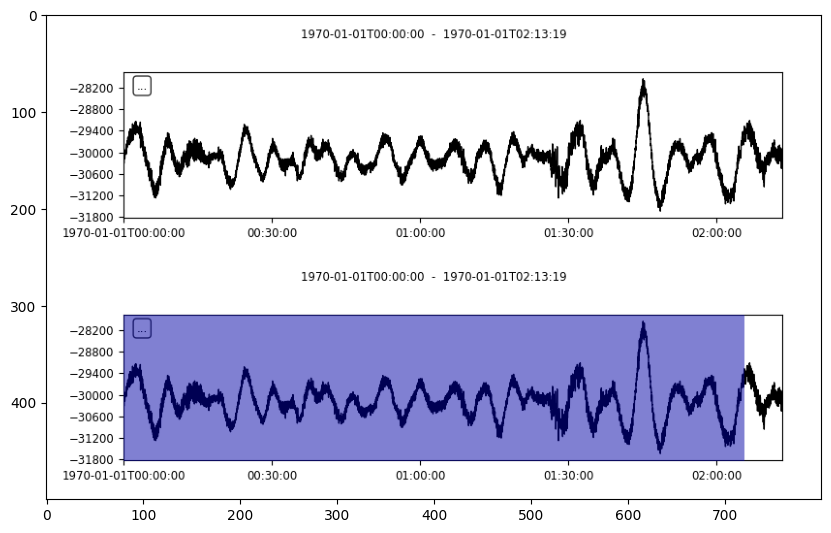

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

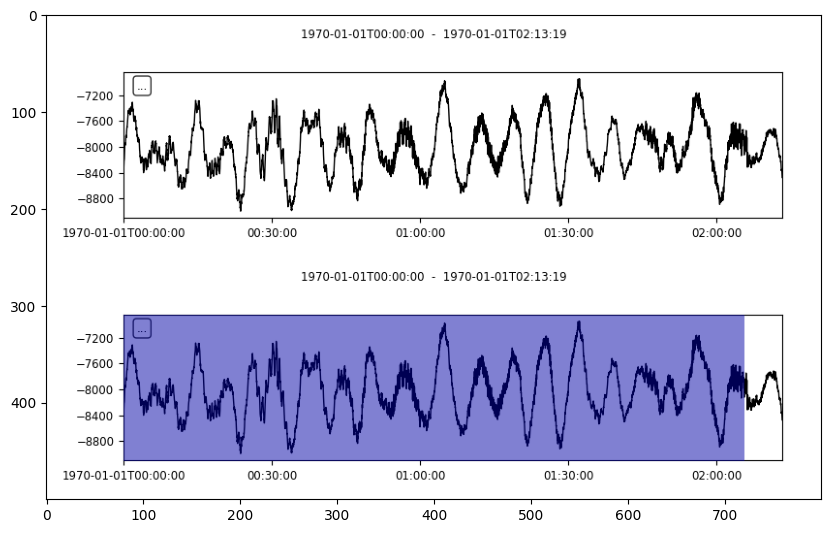

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

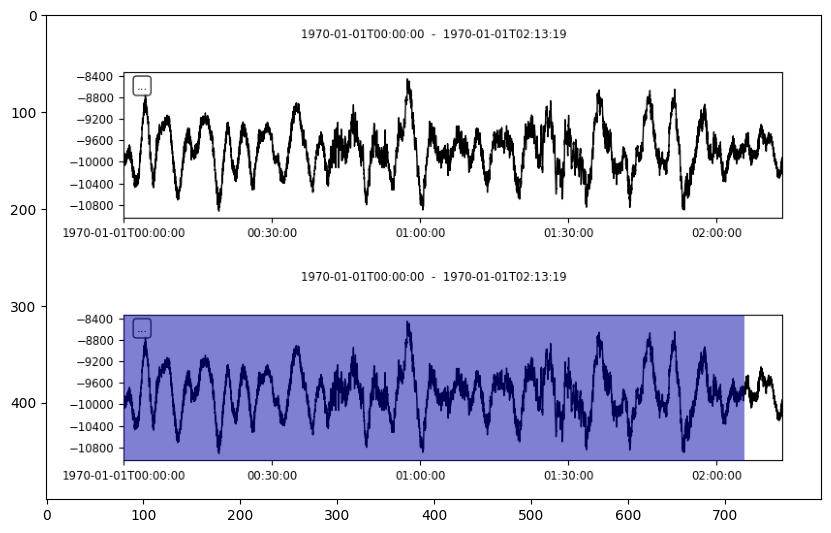

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

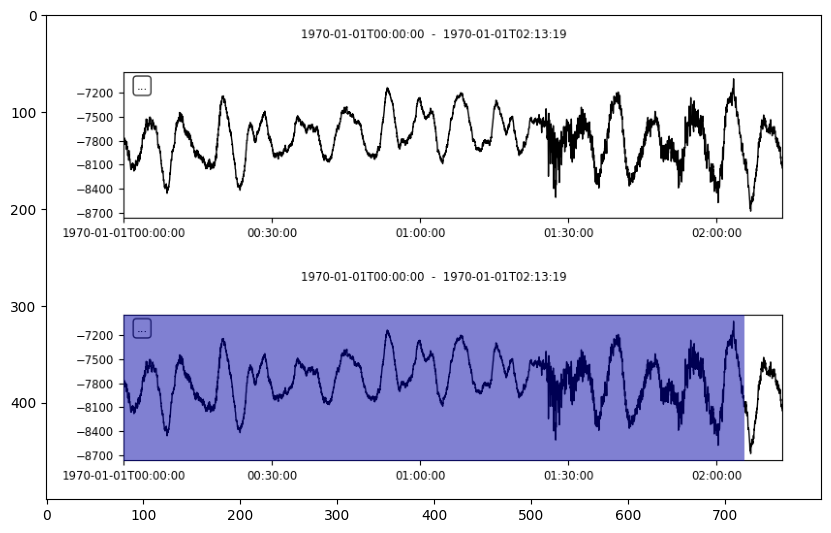

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

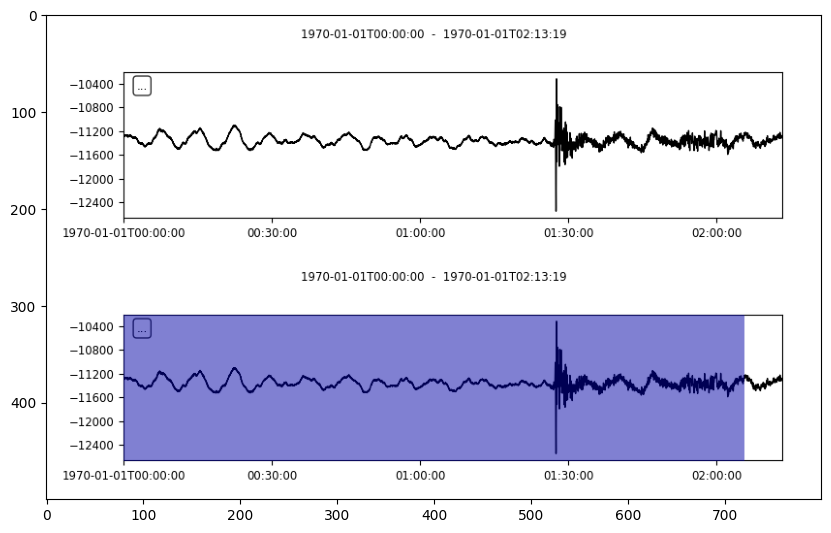

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

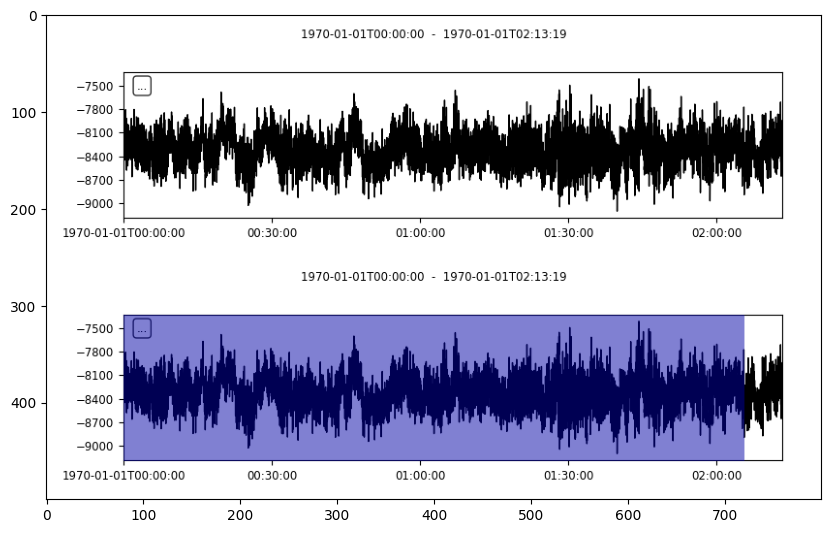

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

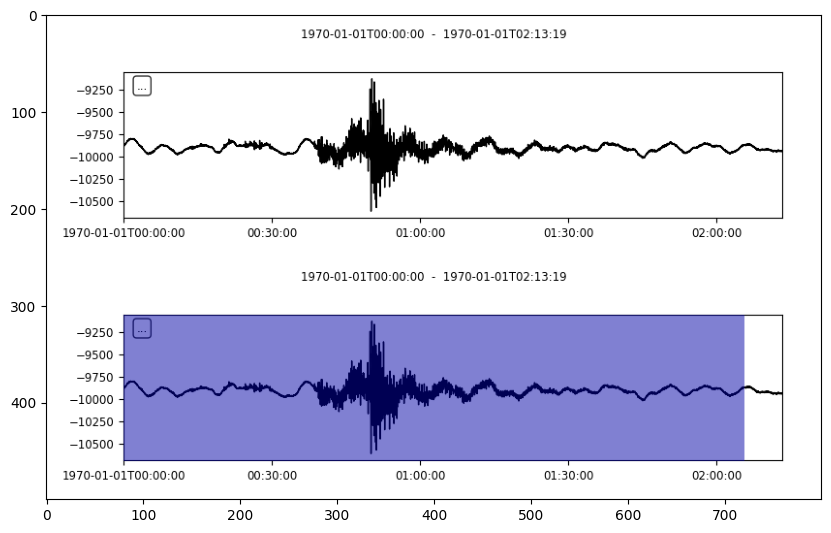

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

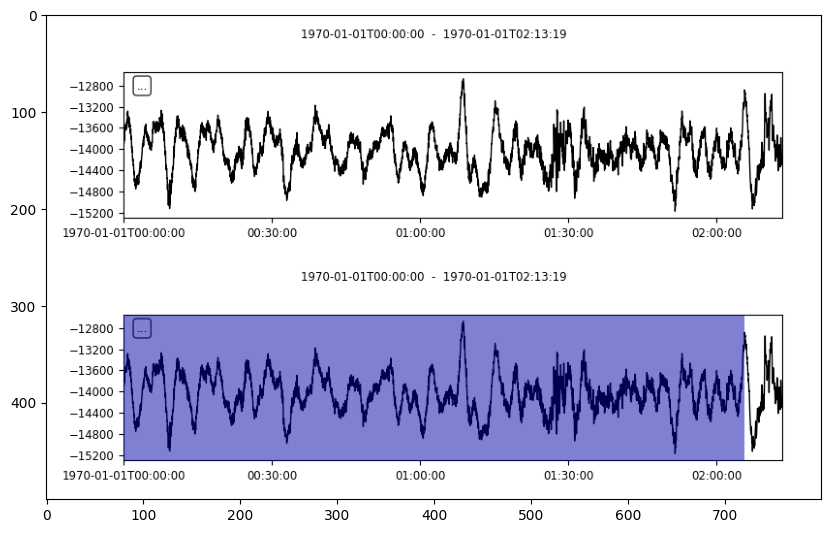

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

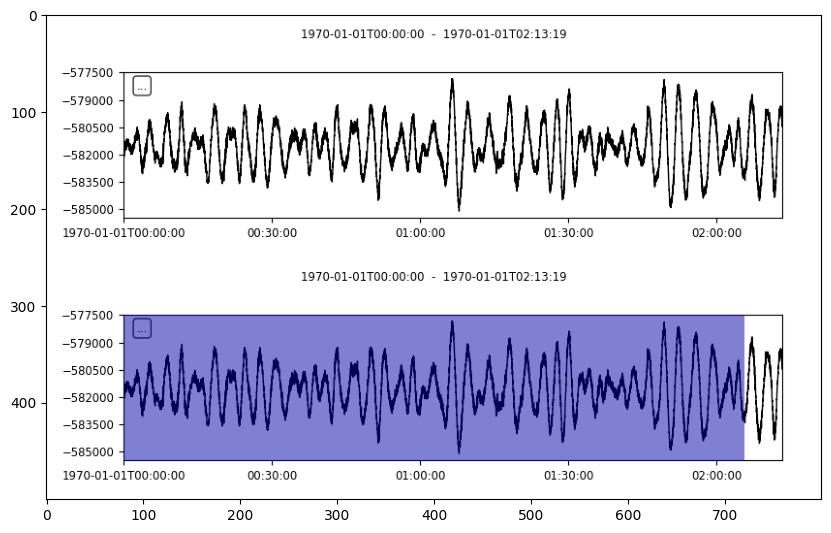

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

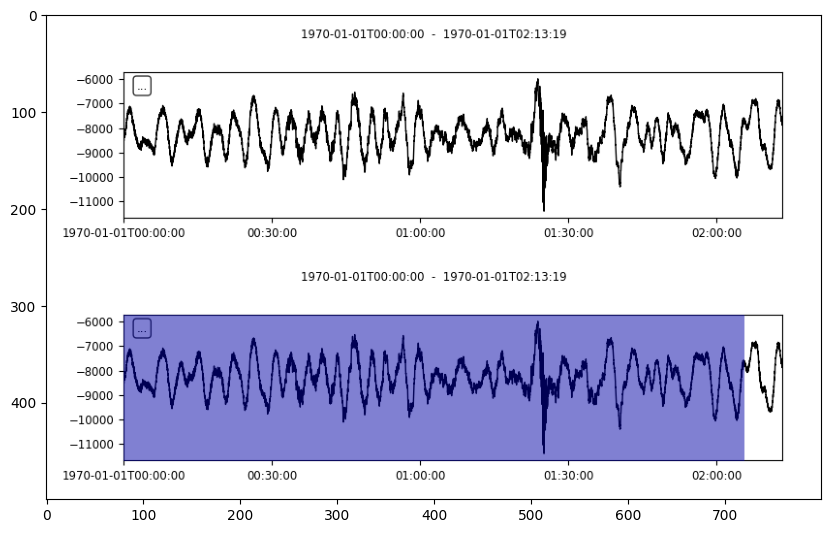

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

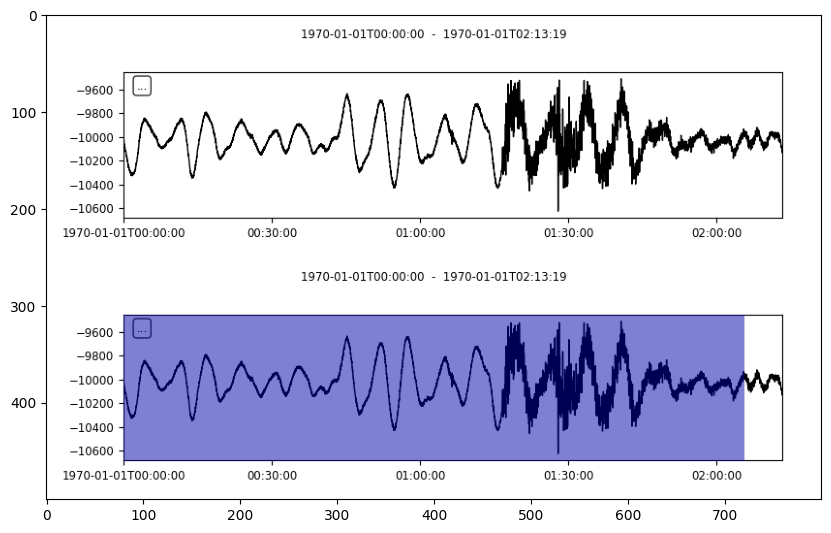

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

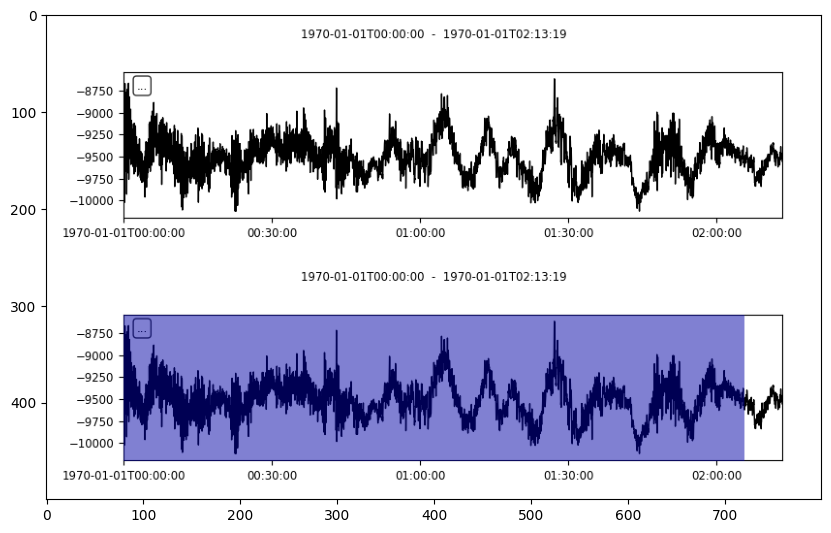

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

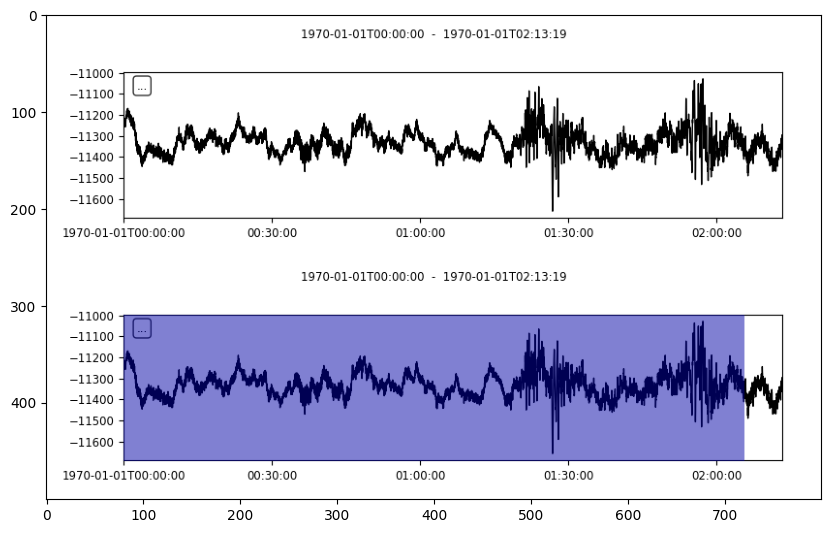

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

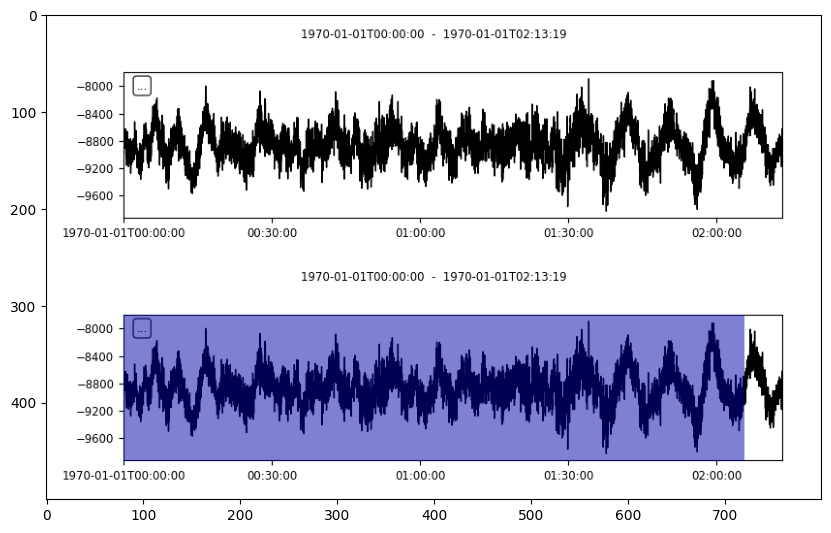

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

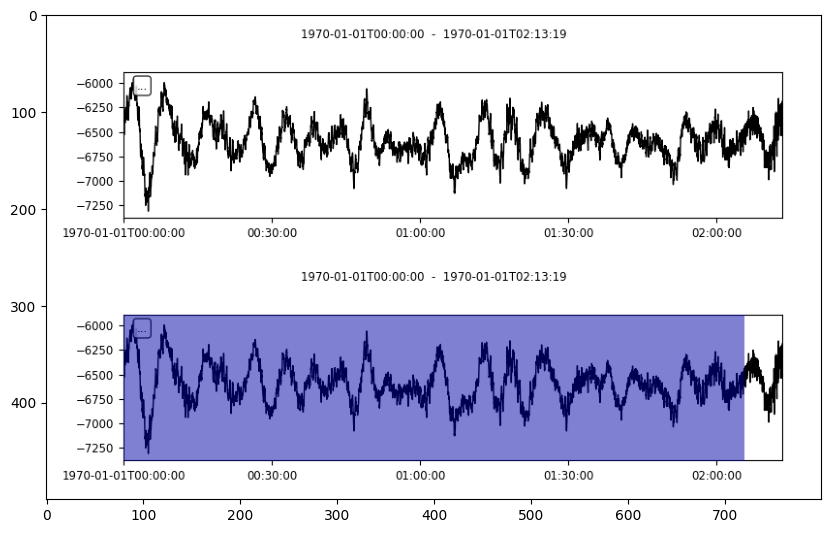

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

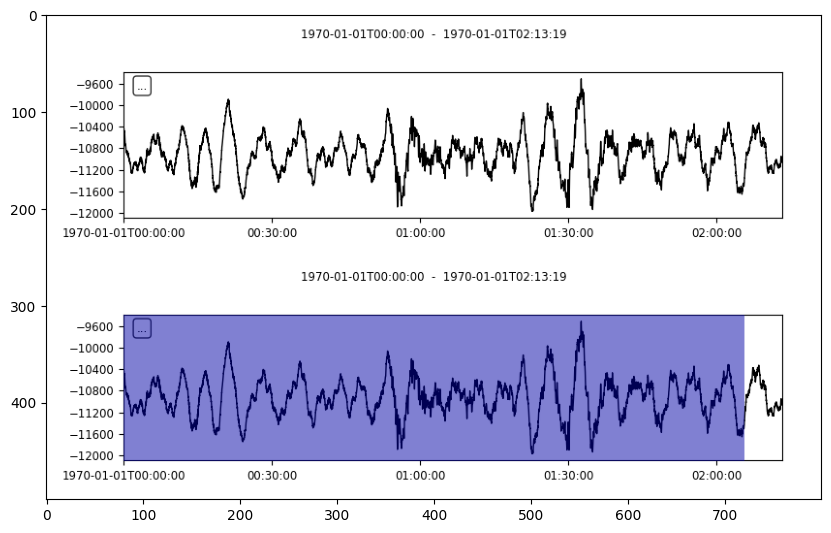

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

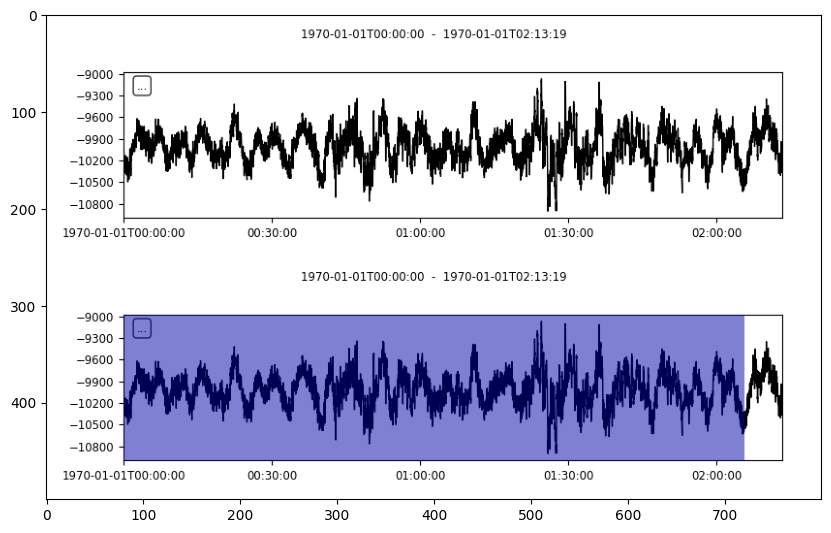

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

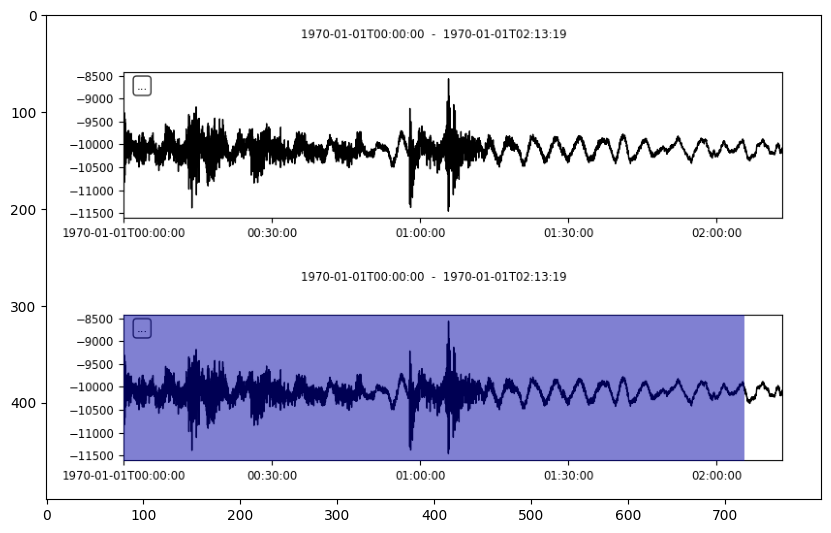

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

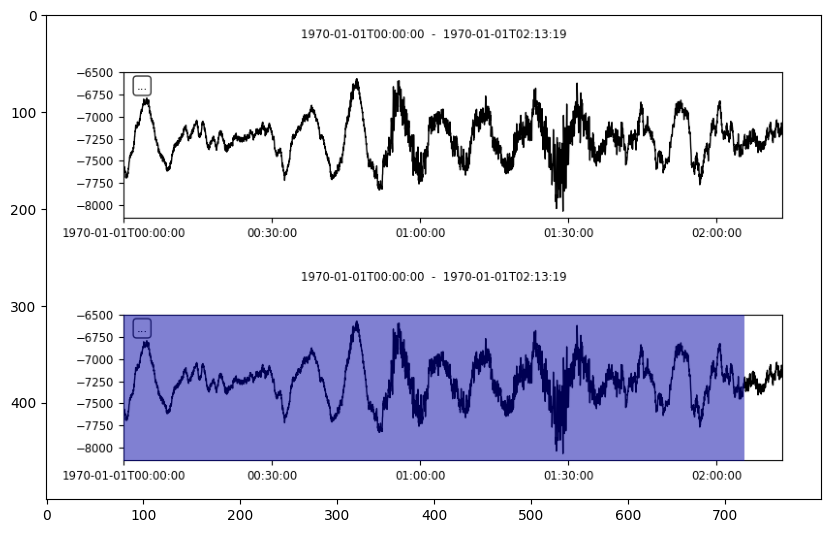

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

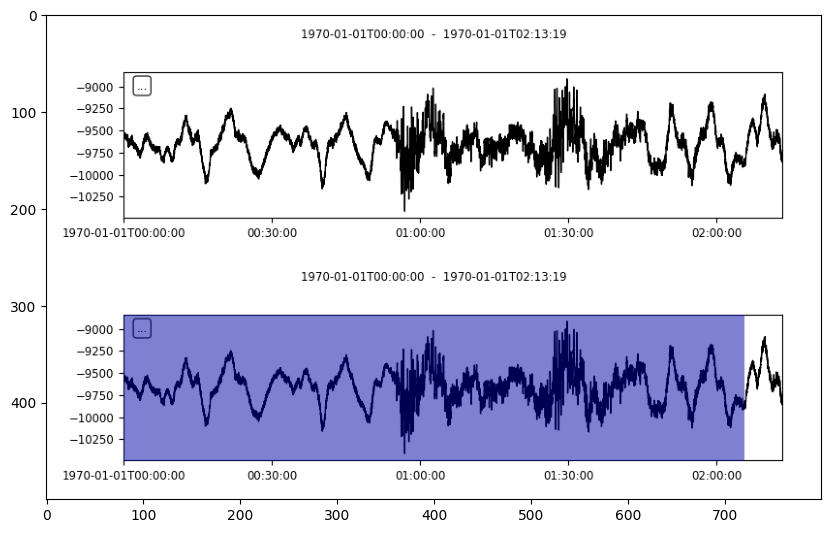

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

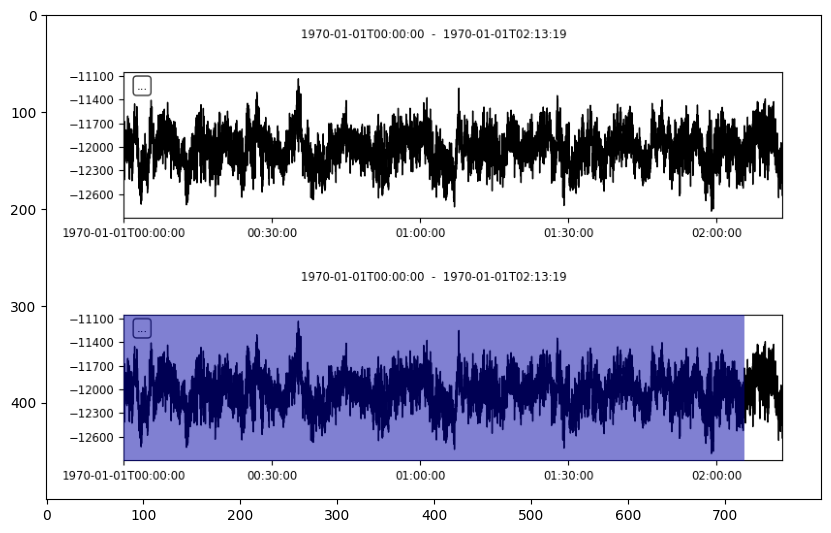

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

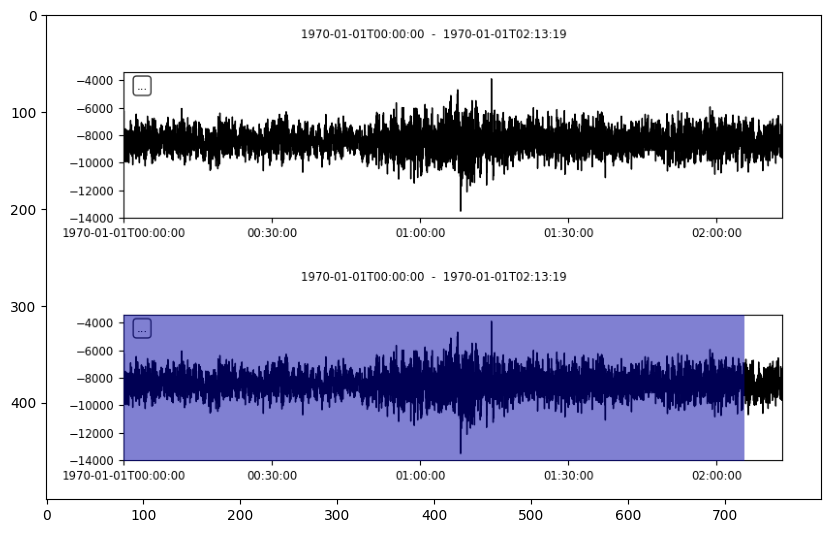

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

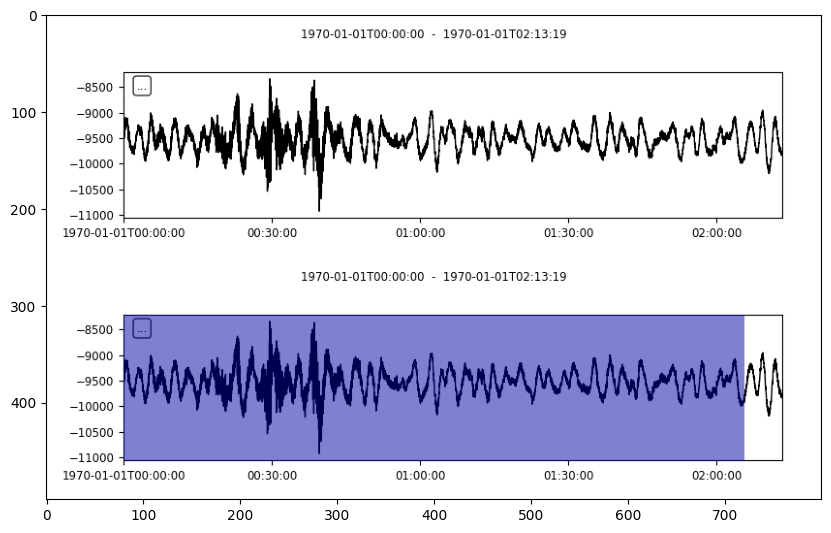

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

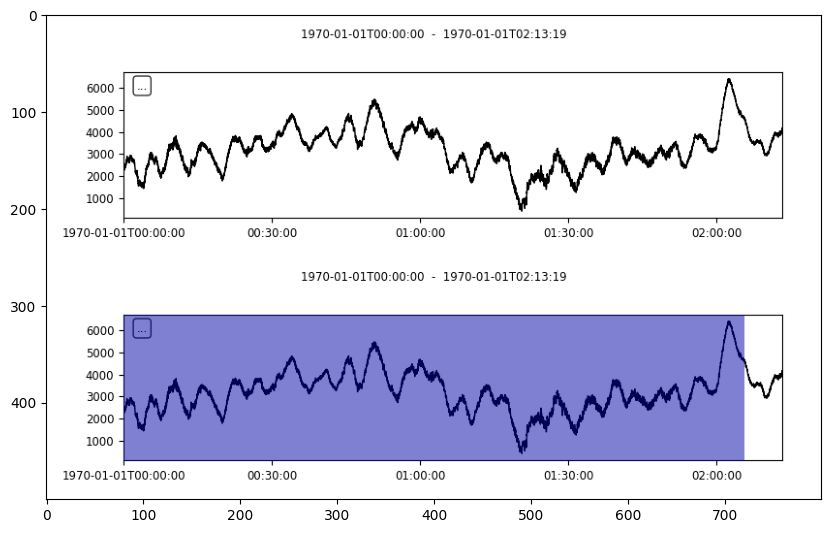

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

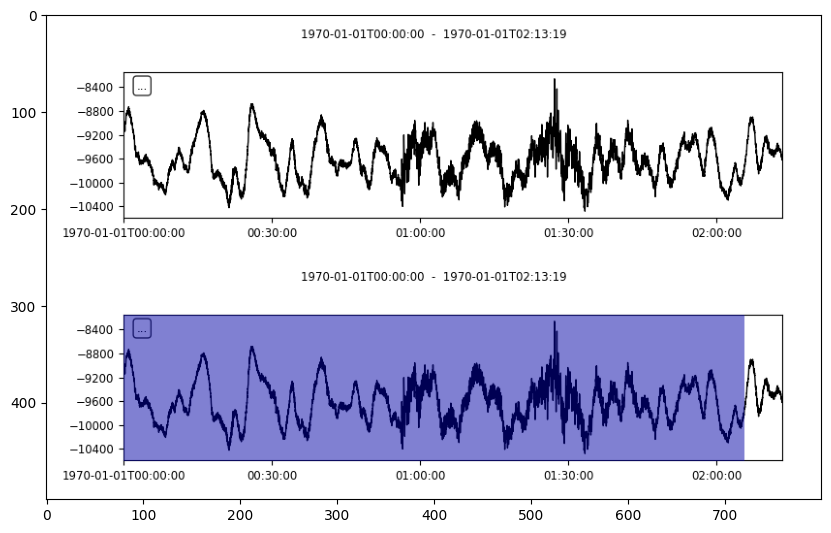

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

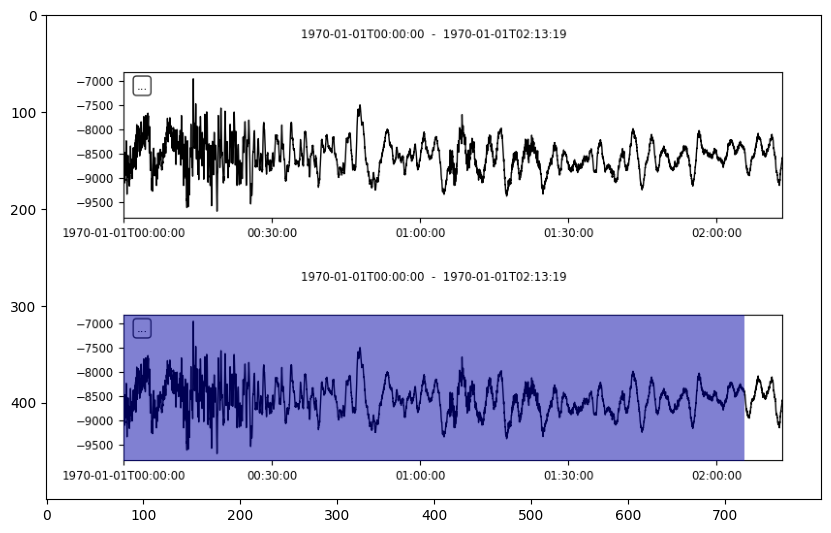

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

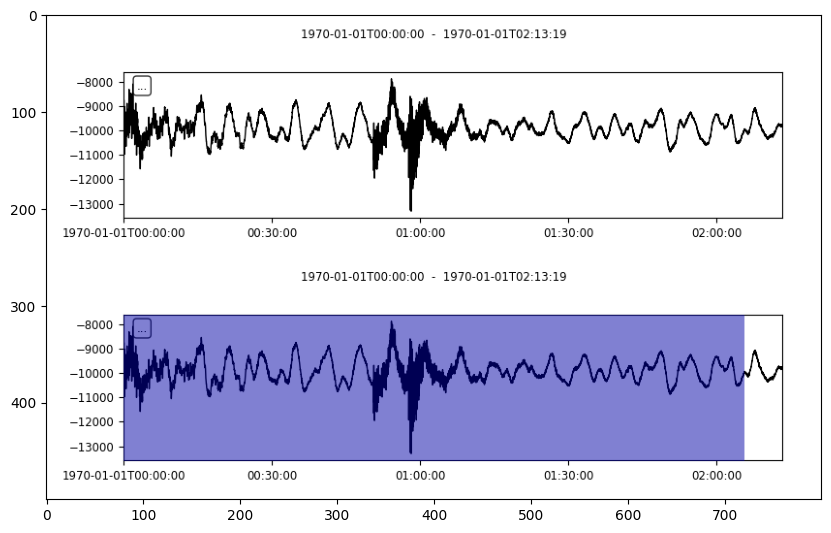

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

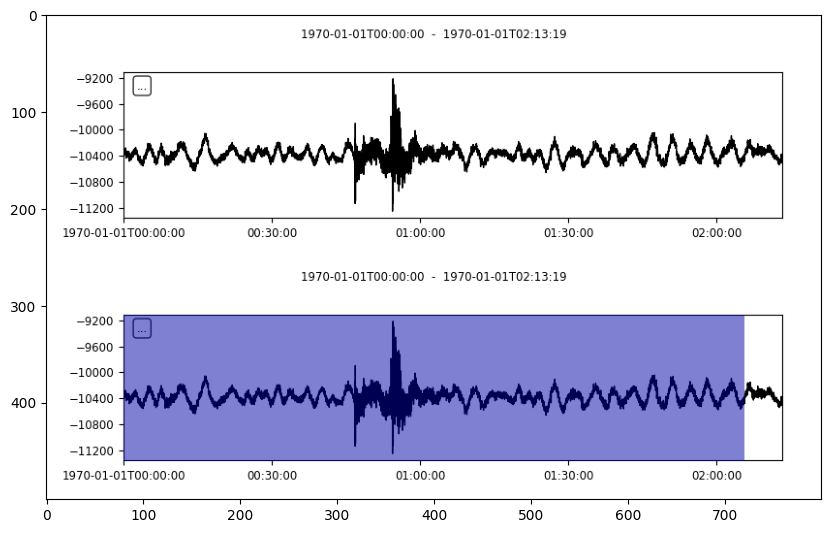

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

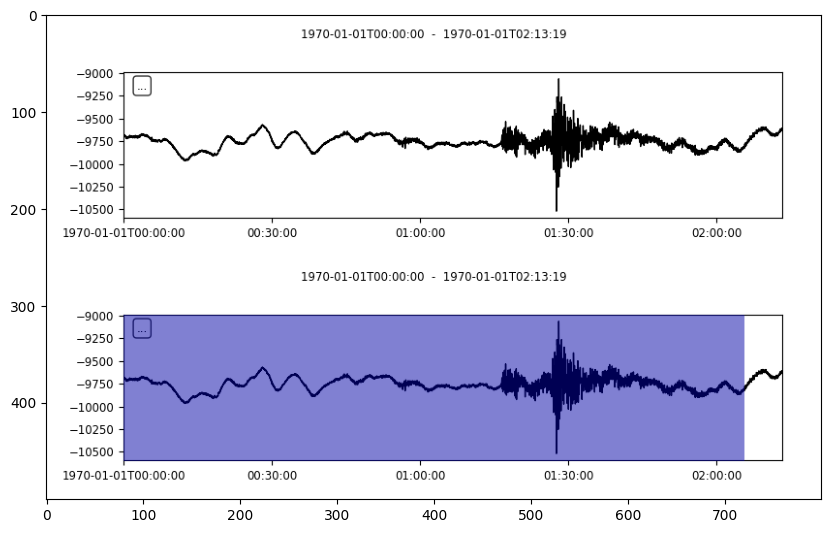

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

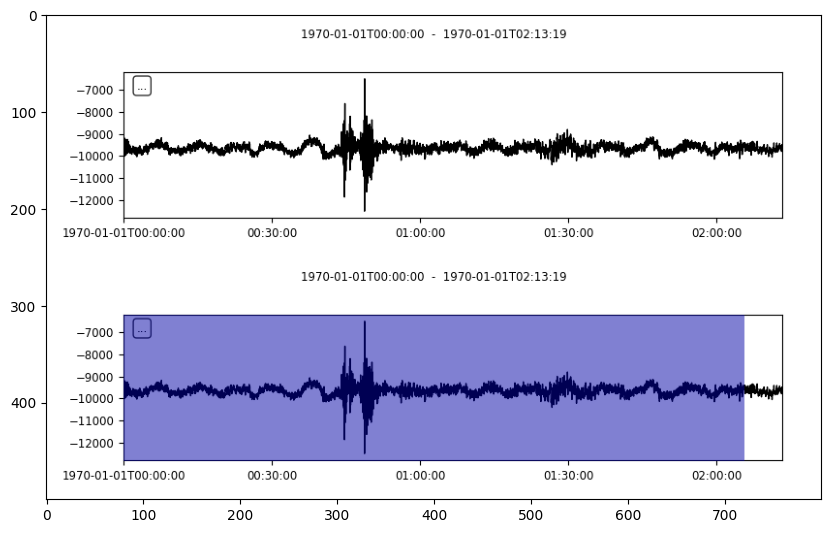

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

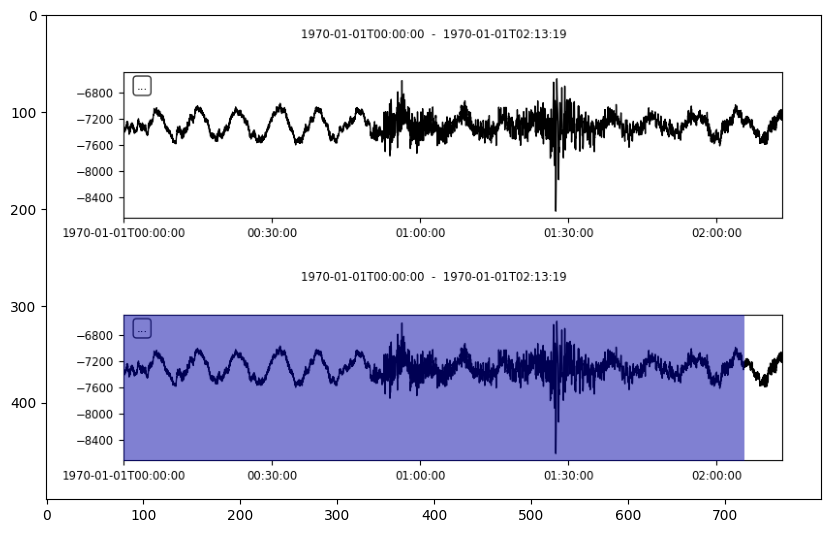

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

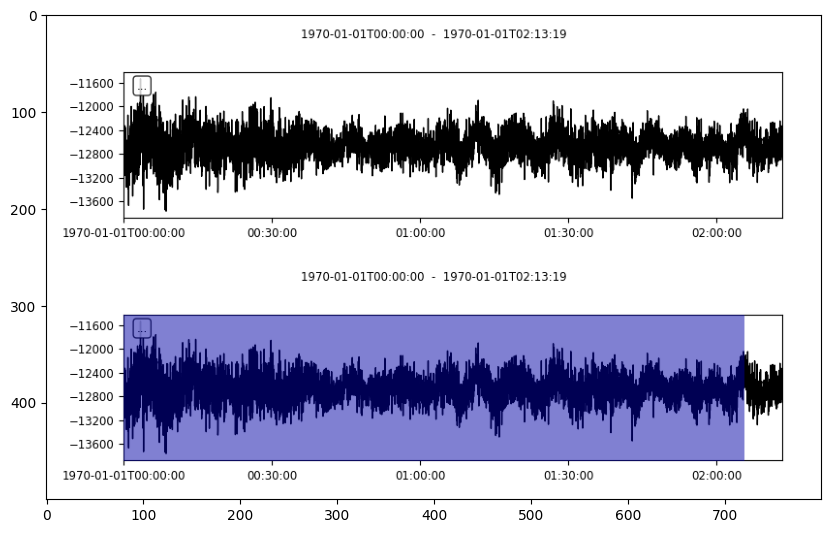

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

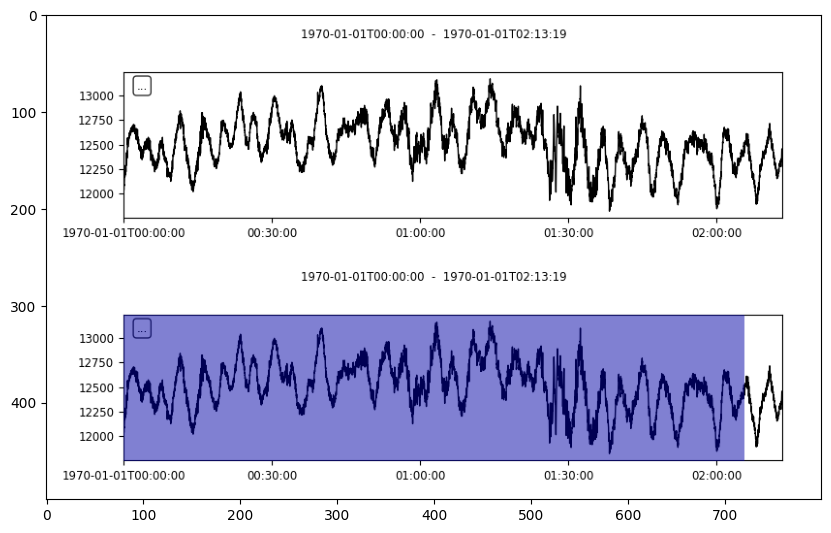

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

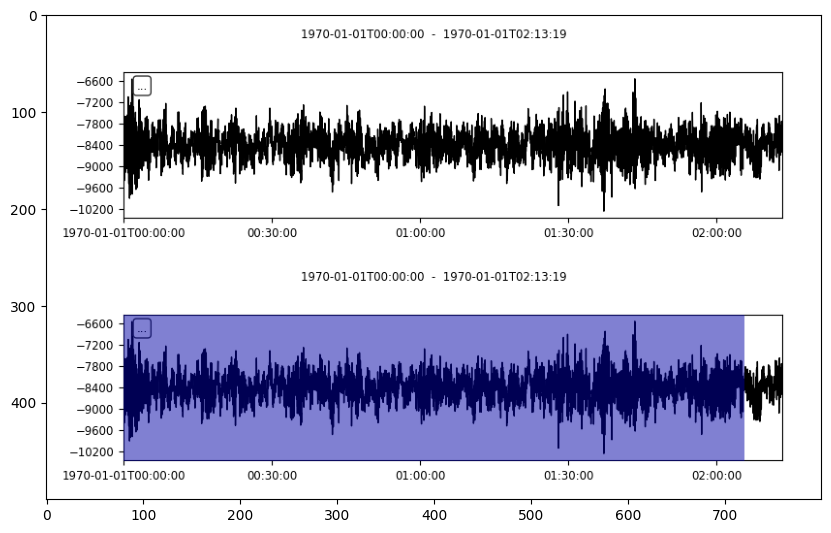

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

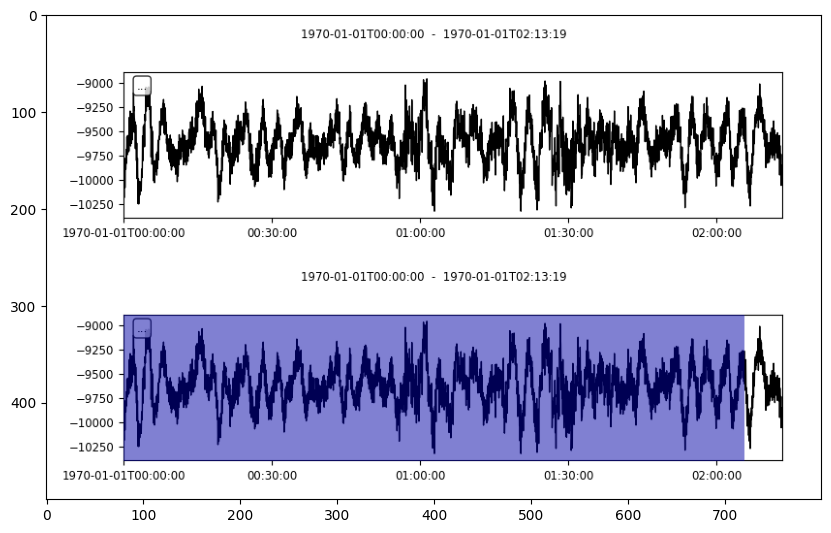

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

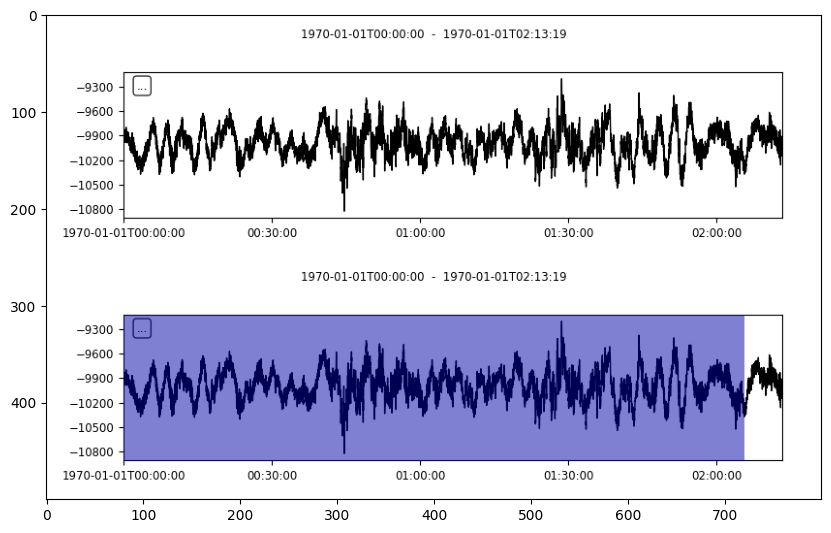

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

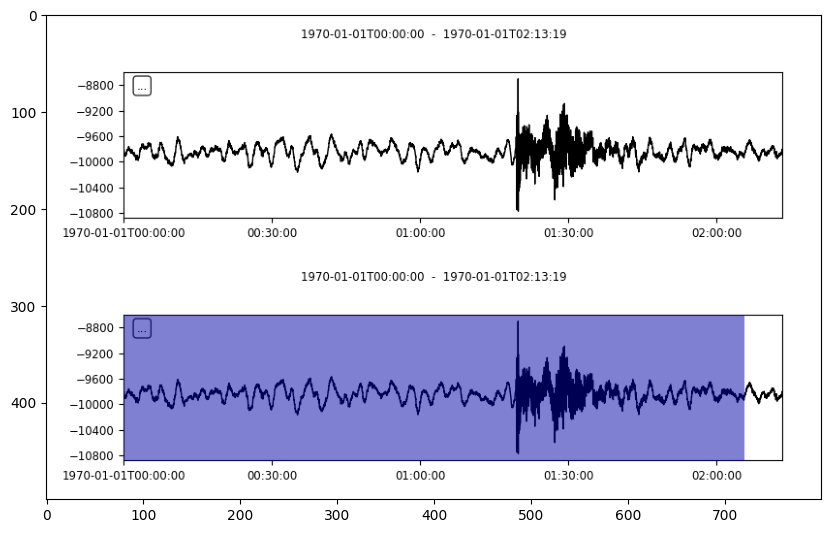

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

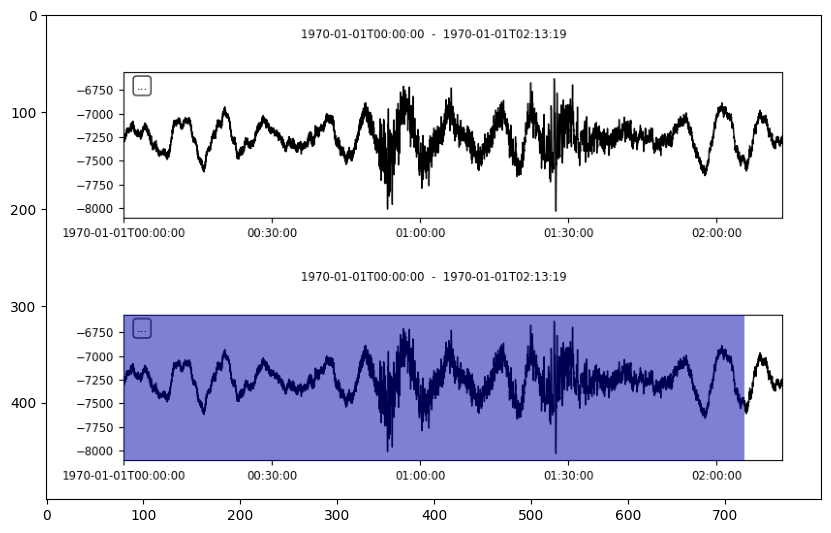

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

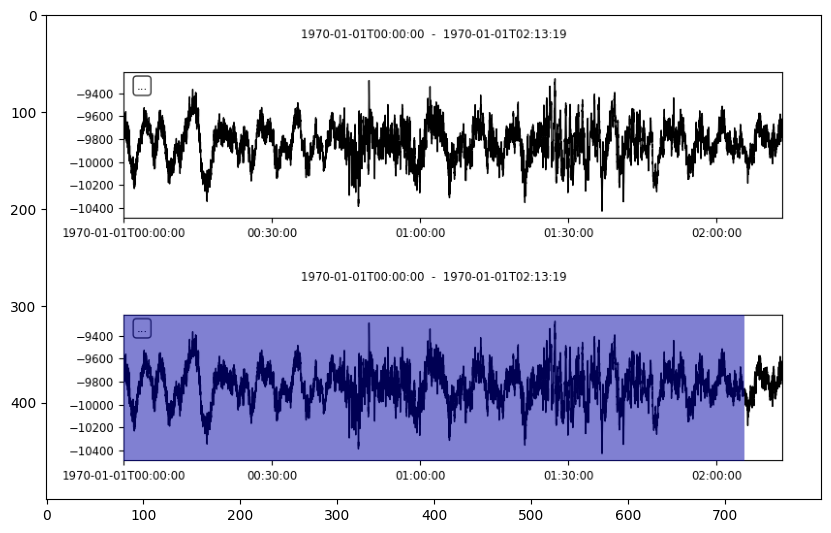

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

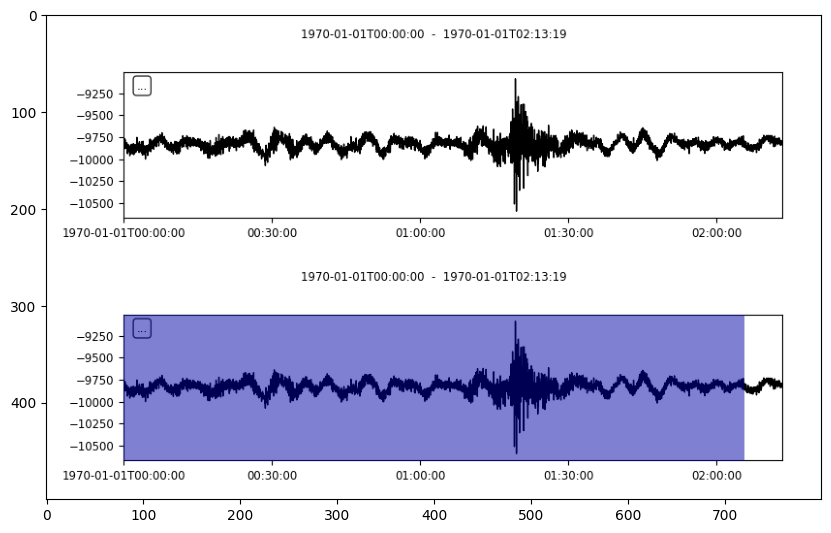

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

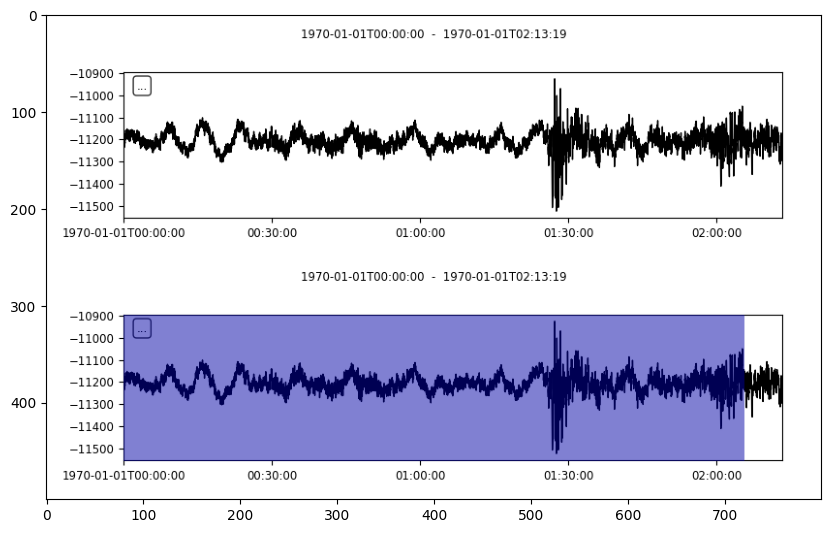

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

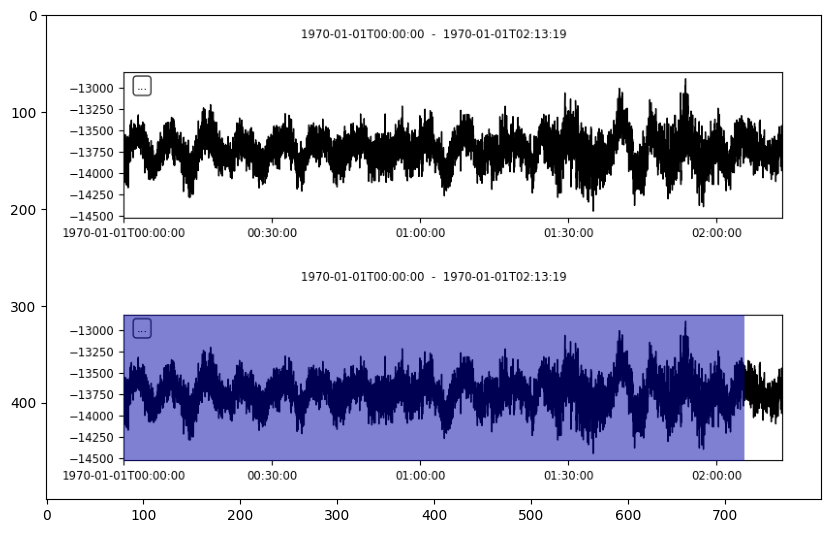

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

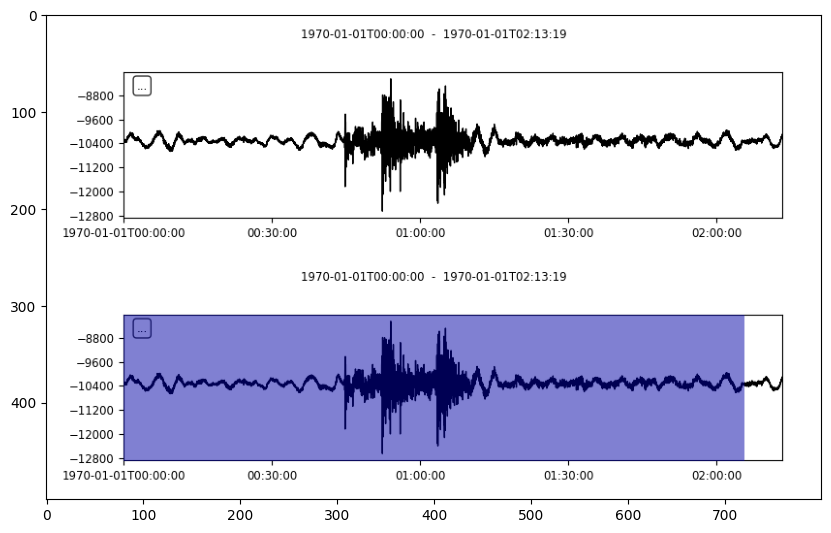

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

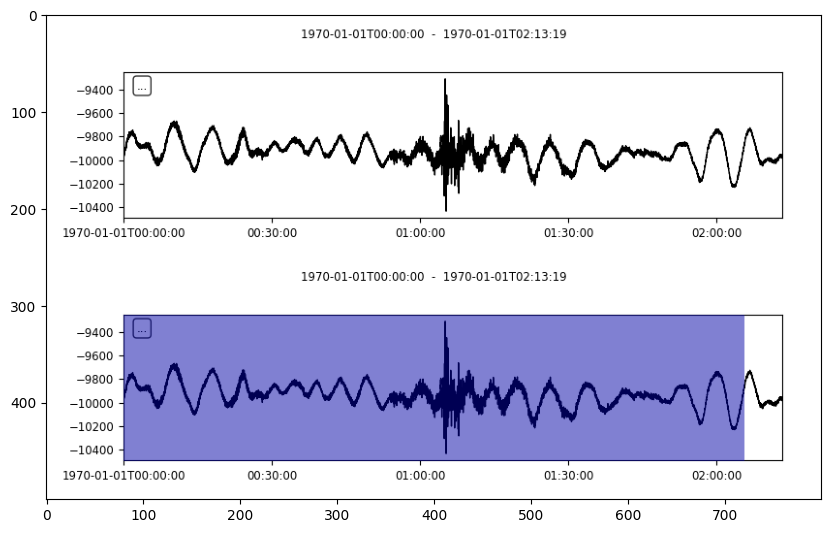

pred [[0.45948073]]
p_l [0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.45948073267936707, 0.4594807

2023-06-22 08:45:30.567852: I tensorflow/core/common_runtime/executor.cc:1197] [/job:localhost/replica:0/task:0/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: Matrix size-incompatible: In[0]: [1,4384], In[1]: [3984,8]
	 [[{{node sequential/dense/Relu}}]]


InvalidArgumentError: Graph execution error:

Detected at node 'sequential/dense/Relu' defined at (most recent call last):
    File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
      exec(code, run_globals)
    File "/home/mbulucay/.local/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
      app.launch_new_instance()
    File "/home/mbulucay/.local/lib/python3.10/site-packages/traitlets/config/application.py", line 1043, in launch_instance
      app.start()
    File "/home/mbulucay/.local/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 725, in start
      self.io_loop.start()
    File "/home/mbulucay/.local/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 215, in start
      self.asyncio_loop.run_forever()
    File "/usr/lib/python3.10/asyncio/base_events.py", line 600, in run_forever
      self._run_once

In [28]:

for trace_file in original_trace_file_list:
    path = os.path.join(dataset, original_class_folder, trace_file) 
    print(f"{index} : {path}")
    index = index + 1
    trace, pred, p_l = colorize(path, divide_number = 80)
    print(f"pred {pred}")
    print(f"p_l {p_l}")
    x = input("Press Enter to continue...")
    if x == 'q':
        break
    elif x == 's':
        # copy the file to another folder
        trace.write("./dataset/" + trace_file, format="SAC")
        cs = cs + 1
        print(f"saved {cs} files")




In [29]:

for trace_file in original_trace_file_list[60:]:
    path = os.path.join(dataset, original_class_folder, trace_file) 
    print(f"{index} : {path}")
    index = index + 1
    trace, pred, p_l = colorize(path, divide_number = 80)
    print(f"pred {pred}")
    print(f"p_l {p_l}")
    x = input("Press Enter to continue...")
    if x == 'q':
        break
    elif x == 's':
        # copy the file to another folder
        trace.write("./dataset/" + trace_file, format="SAC")
        cs = cs + 1
        print(f"saved {cs} files")




60 : dataset8k_v4/class2/original/201905_1_3__KULA.BHZ.KO_original.sac


2023-06-22 08:46:02.588148: I tensorflow/core/common_runtime/executor.cc:1197] [/job:localhost/replica:0/task:0/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: Matrix size-incompatible: In[0]: [1,4384], In[1]: [3984,8]
	 [[{{node sequential/dense/Relu}}]]


InvalidArgumentError: Graph execution error:

Detected at node 'sequential/dense/Relu' defined at (most recent call last):
    File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
      exec(code, run_globals)
    File "/home/mbulucay/.local/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
      app.launch_new_instance()
    File "/home/mbulucay/.local/lib/python3.10/site-packages/traitlets/config/application.py", line 1043, in launch_instance
      app.start()
    File "/home/mbulucay/.local/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 725, in start
      self.io_loop.start()
    File "/home/mbulucay/.local/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 215, in start
      self.asyncio_loop.run_forever()
    File "/usr/lib/python3.10/asyncio/base_events.py", line 600, in run_forever
      self._run_once